## Scope
- [x] One hot encoding
- [x] plot a correlation coefficient
- [x] make interaction features
- [x] test the correlation coefficient of these interaction features

## Notebook 2: Feature Engineering & Finding Business Signals

Once the data has been cleaned, the next step is to transform it into a format that machine learning models can better understand.

In this notebook, I focus on feature engineering, which means creating or transforming variables to help uncover patterns that may not be immediately visible.

Key activities include:

- Converting categorical variables into numerical formats using one-hot encoding.
- Exploring relationships between variables using correlation analysis.
- Creating interaction features that combine customer behaviours and attributes.
- Identifying variables that show the strongest relationship with churn.

The goal is not simply to create more features, but to create meaningful features that reflect customer behaviour and improve predictive performance.

By the end of this notebook, the dataset contains richer information that can help machine learning models identify customers at risk of churning.

### Import the libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

### Load the data

In [2]:
df = pd.read_excel('C:/Users/SMAHI/Downloads/archive/E Commerce Dataset.xlsx', sheet_name="E Comm")

In [3]:
df.head()

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


In [4]:
df.shape

(5630, 20)

In [5]:
df.describe()

,CustomerID,Churn,Tenure,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
count,5630.000000,5630.000000,5366.000000,5630.000000,5379.000000,5375.000000,5630.000000,5630.000000,5630.000000,5630.000000,5365.000000,5374.000000,5372.000000,5323.000000,5630.000000
mean,52815.500000,0.168384,10.189899,1.654707,15.639896,2.931535,3.688988,3.066785,4.214032,0.284902,15.707922,1.751023,3.008004,4.543491,177.223030
std,1625.385339,0.374240,8.557241,0.915389,8.531475,0.721926,1.023999,1.380194,2.583586,0.451408,3.675485,1.894621,2.939680,3.654433,49.207036
min,50001.000000,0.000000,0.000000,1.000000,5.000000,0.000000,1.000000,1.000000,1.000000,0.000000,11.000000,0.000000,1.000000,0.000000,0.000000
25%,51408.250000,0.000000,2.000000,1.000000,9.000000,2.000000,3.000000,2.000000,2.000000,0.000000,13.000000,1.000000,1.000000,2.000000,145.770000
50%,52815.500000,0.000000,9.000000,1.000000,14.000000,3.000000,4.000000,3.000000,3.000000,0.000000,15.000000,1.000000,2.000000,3.000000,163.280000
75%,54222.750000,0.000000,16.000000,3.000000,20.000000,3.000000,4.000000,4.000000,6.000000,1.000000,18.000000,2.000000,3.000000,7.000000,196.392500
max,55630.000000,1.000000,61.000000,3.000000,127.000000,5.000000,6.000000,5.000000,22.000000,1.000000,26.000000,16.000000,16.000000,46.000000,324.990000


In [6]:
# Check for nulls
df.isnull().sum()

CustomerID                       0
Churn                            0
Tenure                         264
PreferredLoginDevice             0
CityTier                         0
WarehouseToHome                251
PreferredPaymentMode             0
Gender                           0
HourSpendOnApp                 255
NumberOfDeviceRegistered         0
PreferedOrderCat                 0
SatisfactionScore                0
MaritalStatus                    0
NumberOfAddress                  0
Complain                         0
OrderAmountHikeFromlastYear    265
CouponUsed                     256
OrderCount                     258
DaySinceLastOrder              307
CashbackAmount                   0
dtype: int64

- So now the max null count any of the column has 307 which is 5.72% so removing these many columns will be fine but filling these if we can will be preferred

- All the columns which has null values are all numerical but categorical in some way so keeping that in mind, filling the nulls with median can be done

### Data cleaning

In [7]:
# Impute missing numerical values with median
cols_to_impute = [
    'Tenure', 'WarehouseToHome', 'HourSpendOnApp',
    'OrderAmountHikeFromlastYear', 'CouponUsed',
    'OrderCount', 'DaySinceLastOrder'
]

In [8]:
for col in cols_to_impute:
    df[col].fillna(df[col].median(), inplace=True)

In [9]:
# validate the filling of nulls
df.isnull().sum()

CustomerID                     0
Churn                          0
Tenure                         0
PreferredLoginDevice           0
CityTier                       0
WarehouseToHome                0
PreferredPaymentMode           0
Gender                         0
HourSpendOnApp                 0
NumberOfDeviceRegistered       0
PreferedOrderCat               0
SatisfactionScore              0
MaritalStatus                  0
NumberOfAddress                0
Complain                       0
OrderAmountHikeFromlastYear    0
CouponUsed                     0
OrderCount                     0
DaySinceLastOrder              0
CashbackAmount                 0
dtype: int64

In [10]:
# Drop the col customer id because that is just an identifier and hold no significant value, infact it can bias the model
df.drop(columns=['CustomerID'], inplace=True)

In [11]:
# Check categories of the categorical value
df.nunique()

Churn                             2
Tenure                           36
PreferredLoginDevice              3
CityTier                          3
WarehouseToHome                  34
PreferredPaymentMode              7
Gender                            2
HourSpendOnApp                    6
NumberOfDeviceRegistered          6
PreferedOrderCat                  6
SatisfactionScore                 5
MaritalStatus                     3
NumberOfAddress                  15
Complain                          2
OrderAmountHikeFromlastYear      16
CouponUsed                       17
OrderCount                       16
DaySinceLastOrder                22
CashbackAmount                 2586
dtype: int64

In [12]:
# Change column names to lowercase
df.columns = [col.lower() for col in df.columns]
df.columns

Index(['churn', 'tenure', 'preferredlogindevice', 'citytier',
       'warehousetohome', 'preferredpaymentmode', 'gender', 'hourspendonapp',
       'numberofdeviceregistered', 'preferedordercat', 'satisfactionscore',
       'maritalstatus', 'numberofaddress', 'complain',
       'orderamounthikefromlastyear', 'couponused', 'ordercount',
       'daysincelastorder', 'cashbackamount'],
      dtype='object')

In [13]:
df.churn.value_counts()

0    4682
1     948
Name: churn, dtype: int64

**Stratified Split**: Since churn is a binary classification problem, it's important to maintain the proportion of churned and non-churned customers in both training and testing sets.

In [14]:
## Train test split
from sklearn.model_selection import train_test_split

X = df.drop('churn', axis=1)
y = df['churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


**Validation Set**: To fine-tune hyperparameters and prevent overfitting, consider splitting your training data further into training and validation sets.

In [15]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.25, stratify=y_train, random_state=42
)


In [16]:
df.head()

,churn,tenure,preferredlogindevice,citytier,warehousetohome,preferredpaymentmode,gender,hourspendonapp,numberofdeviceregistered,preferedordercat,satisfactionscore,maritalstatus,numberofaddress,complain,orderamounthikefromlastyear,couponused,ordercount,daysincelastorder,cashbackamount
0,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,1,9.0,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,1,9.0,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,1,0.0,Phone,1,12.0,CC,Male,3.0,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


## One hot encoding

In [17]:
# One-hot encode relevant categorical columns for full correlation matrix
# For a full correlation matrix, you'd ideally one-hot encode all nominal categorical features.
# Let's pick a few for illustration:
categorical_cols_to_encode = ['preferredlogindevice', 'preferredpaymentmode', 'gender', 'maritalstatus', 'preferedordercat']
df_encoded = pd.get_dummies(df, columns=categorical_cols_to_encode, drop_first=True) # drop_first avoids multicollinearity for OHE


# Now, calculate the correlation matrix for the relevant columns including Churn
# Ensure all columns are numeric
numeric_df = df_encoded.select_dtypes(include=['number'])
correlation_matrix = numeric_df.corr()

# Get correlations with the 'Churn' column
churn_correlations = correlation_matrix['churn'].sort_values(ascending=False)
print("Correlations with Churn:\n", churn_correlations)

Correlations with Churn:
 churn                                    1.000000
complain                                 0.250188
maritalstatus_Single                     0.180847
preferedordercat_Mobile Phone            0.154387
preferedordercat_Mobile                  0.113364
numberofdeviceregistered                 0.107939
satisfactionscore                        0.105481
citytier                                 0.084703
preferredpaymentmode_COD                 0.083933
preferredlogindevice_Phone               0.078916
warehousetohome                          0.069544
preferredpaymentmode_E wallet            0.055751
numberofaddress                          0.043931
gender_Male                              0.029264
hourspendonapp                           0.018816
preferredpaymentmode_UPI                 0.004163
couponused                              -0.001430
preferredpaymentmode_Cash on Delivery   -0.006178
orderamounthikefromlastyear             -0.007075
ordercount              

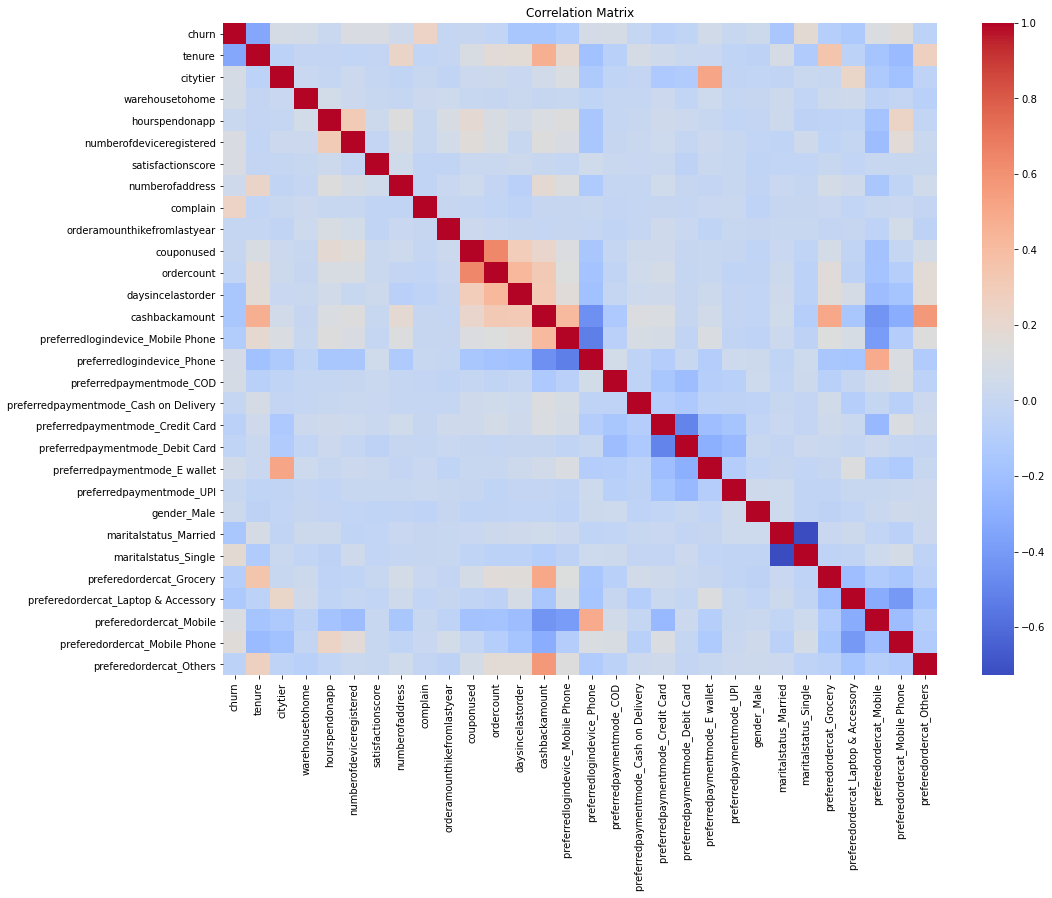

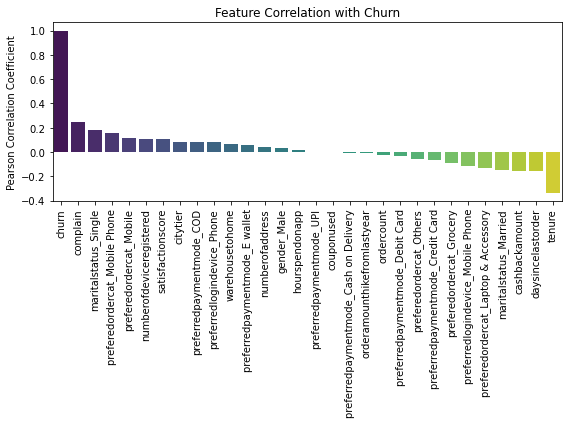

In [18]:
# Visualize the correlation matrix (heatmap)
plt.figure(figsize=(16, 12))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

# --- Specific Correlation with Churn (for important features) ---
plt.figure(figsize=(8, 6))
sns.barplot(x=churn_correlations.index, y=churn_correlations.values, palette='viridis')
plt.xticks(rotation=90)
plt.title('Feature Correlation with Churn')
plt.ylabel('Pearson Correlation Coefficient')
plt.tight_layout()
plt.show()

In [19]:
print("\nCreating interaction features...")

# Interaction 1: Tenure x Complain
# This captures if a long-term customer has recently complained.
# A higher value here might indicate a higher risk of churn.
df['Tenure_x_Complain'] = df['tenure'] * df['complain']
print("Created 'Tenure_x_Complain'")

# Interaction 2: HourSpendOnApp x NumberOfDeviceRegistered
# This could indicate overall engagement across devices.
# A higher value might suggest more active and integrated usage.
df['HourSpendOnApp_x_NumberOfDeviceRegistered'] = df['hourspendonapp'] * df['numberofdeviceregistered']
print("Created 'HourSpendOnApp_x_NumberOfDeviceRegistered'")

# Interaction 3: OrderAmountHikeFromlastYear x CouponUsed
# This might highlight customers who increased spending but only due to coupons,
# suggesting price sensitivity.
df['OrderAmountHikeFromlastYear_x_CouponUsed'] = df['orderamounthikefromlastyear'] * df['couponused']
print("Created 'OrderAmountHikeFromlastYear_x_CouponUsed'")

# Interaction 4: CashbackAmount x OrderCount
# This could show if customers with high cashback also make many orders,
# indicating loyalty driven by incentives.
df['CashbackAmount_x_OrderCount'] = df['cashbackamount'] * df['ordercount']
print("Created 'CashbackAmount_x_OrderCount'")


Creating interaction features...
Created 'Tenure_x_Complain'
Created 'HourSpendOnApp_x_NumberOfDeviceRegistered'
Created 'OrderAmountHikeFromlastYear_x_CouponUsed'
Created 'CashbackAmount_x_OrderCount'


In [21]:
# --- 4. Calculate Correlation of New Features with Churn ---

print("\nCalculating correlations of new features with 'Churn':")

# Select the new interaction features and the 'Churn' column
interaction_features = [
    'Tenure_x_Complain',
    'HourSpendOnApp_x_NumberOfDeviceRegistered',
    'OrderAmountHikeFromlastYear_x_CouponUsed',
    'CashbackAmount_x_OrderCount'
]

# Ensure all selected columns are numeric for correlation calculation
# (This check was already done for original columns, but good to be explicit for new ones)
for col in interaction_features:
    if col not in df.columns:
        print(f"Warning: Interaction feature '{col}' was not created. Skipping correlation.")
        continue
    if df[col].dtype == 'object':
        df[col] = pd.to_numeric(df[col], errors='coerce')
        df.dropna(subset=[col], inplace=True) # Drop rows if conversion resulted in NaNs
        print(f"Converted '{col}' to numeric and dropped any new NaNs.")


# Calculate correlations
correlations_with_churn = df[interaction_features + ['churn']].corr()['churn'].drop('churn')



Calculating correlations of new features with 'Churn':



--- Correlation of New Interaction Features with Churn ---
HourSpendOnApp_x_NumberOfDeviceRegistered    0.080004
OrderAmountHikeFromlastYear_x_CouponUsed    -0.007909
CashbackAmount_x_OrderCount                 -0.046973
Tenure_x_Complain                           -0.049355
Name: churn, dtype: float64


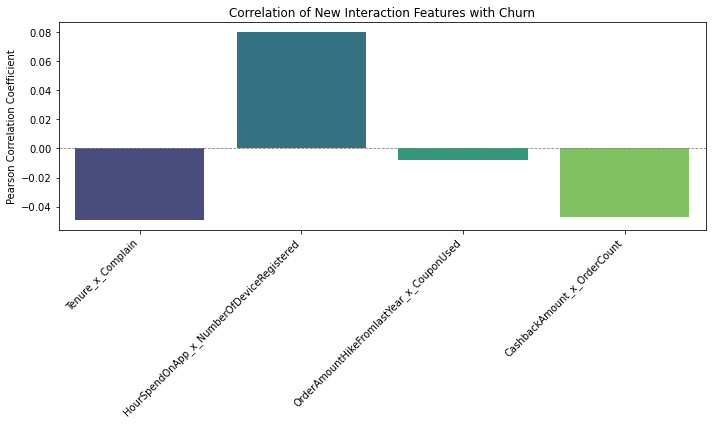


Interpretation Notes:
- A positive correlation means as the interaction feature increases, churn tends to increase.
- A negative correlation means as the interaction feature increases, churn tends to decrease.
- The closer the value is to 1 or -1, the stronger the linear relationship.


In [22]:
# --- 5. Display the Correlations ---
print("\n--- Correlation of New Interaction Features with Churn ---")
print(correlations_with_churn.sort_values(ascending=False))

# Optional: Visualize the correlations
plt.figure(figsize=(10, 6))
sns.barplot(x=correlations_with_churn.index, y=correlations_with_churn.values, palette='viridis')
plt.xticks(rotation=45, ha='right')
plt.title('Correlation of New Interaction Features with Churn')
plt.ylabel('Pearson Correlation Coefficient')
plt.axhline(0, color='grey', linestyle='--', linewidth=0.8) # Add a line at 0 for reference
plt.tight_layout()
plt.show()

print("\nInterpretation Notes:")
print("- A positive correlation means as the interaction feature increases, churn tends to increase.")
print("- A negative correlation means as the interaction feature increases, churn tends to decrease.")
print("- The closer the value is to 1 or -1, the stronger the linear relationship.")
